# Vehicle Insurance Fraud Detection using Machine Learning

## Problem Statement

Insurance fraud is a major challenge for insurance companies, leading to significant financial losses and increased operational costs. Detecting fraudulent claims manually is time-consuming and often ineffective due to the large volume of claims processed every day. Therefore, there is a need for an automated machine learning solution that can identify potentially fraudulent claims based on historical insurance data.

---


## Objective

The objective of this project is to build a robust machine learning model capable of identifying fraudulent vehicle insurance claims using historical claim data. The proposed solution aims to improve fraud detection by leveraging data preprocessing, class imbalance handling, model comparison, hyperparameter optimization, and explainability techniques, ultimately supporting faster and more reliable decision-making for insurance companies.

---

## Project Workflow

- Understand the dataset and business problem
- Perform Exploratory Data Analysis (EDA)
- Preprocess the data
- Handle class imbalance using SMOTE
- Train multiple classification models
- Compare model performance
- Optimize the best-performing model using GridSearchCV
- Evaluate the final model using multiple performance metrics
- Interpret the model using feature importance
- Summarize findings and discuss future improvements

##  DATASET OVERVIEW

In [29]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline



In [30]:
# Load Dataset
df = pd.read_csv("C:\\Users\\admin\\Desktop\\Classification placement project\\fraud_oracle.csv")  # use your exact filename
df.head()


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [31]:
# Basic Overview
print(df.shape)
print(df.info())
print(df.describe())

(15420, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15

##  EDA

FraudFound_P
0    14497
1      923
Name: count, dtype: int64
FraudFound_P
0    94.014267
1     5.985733
Name: proportion, dtype: float64


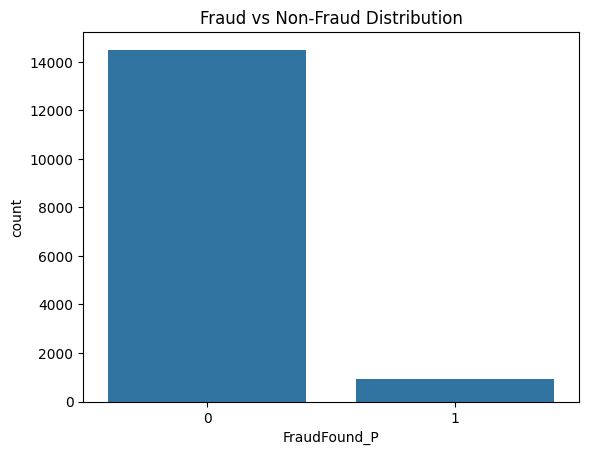

In [32]:
# Check fraud distribution
print(df['FraudFound_P'].value_counts())
print(df['FraudFound_P'].value_counts(normalize=True) * 100)

# Visualize
sns.countplot(x='FraudFound_P', data=df)
plt.title('Fraud vs Non-Fraud Distribution')
plt.show()

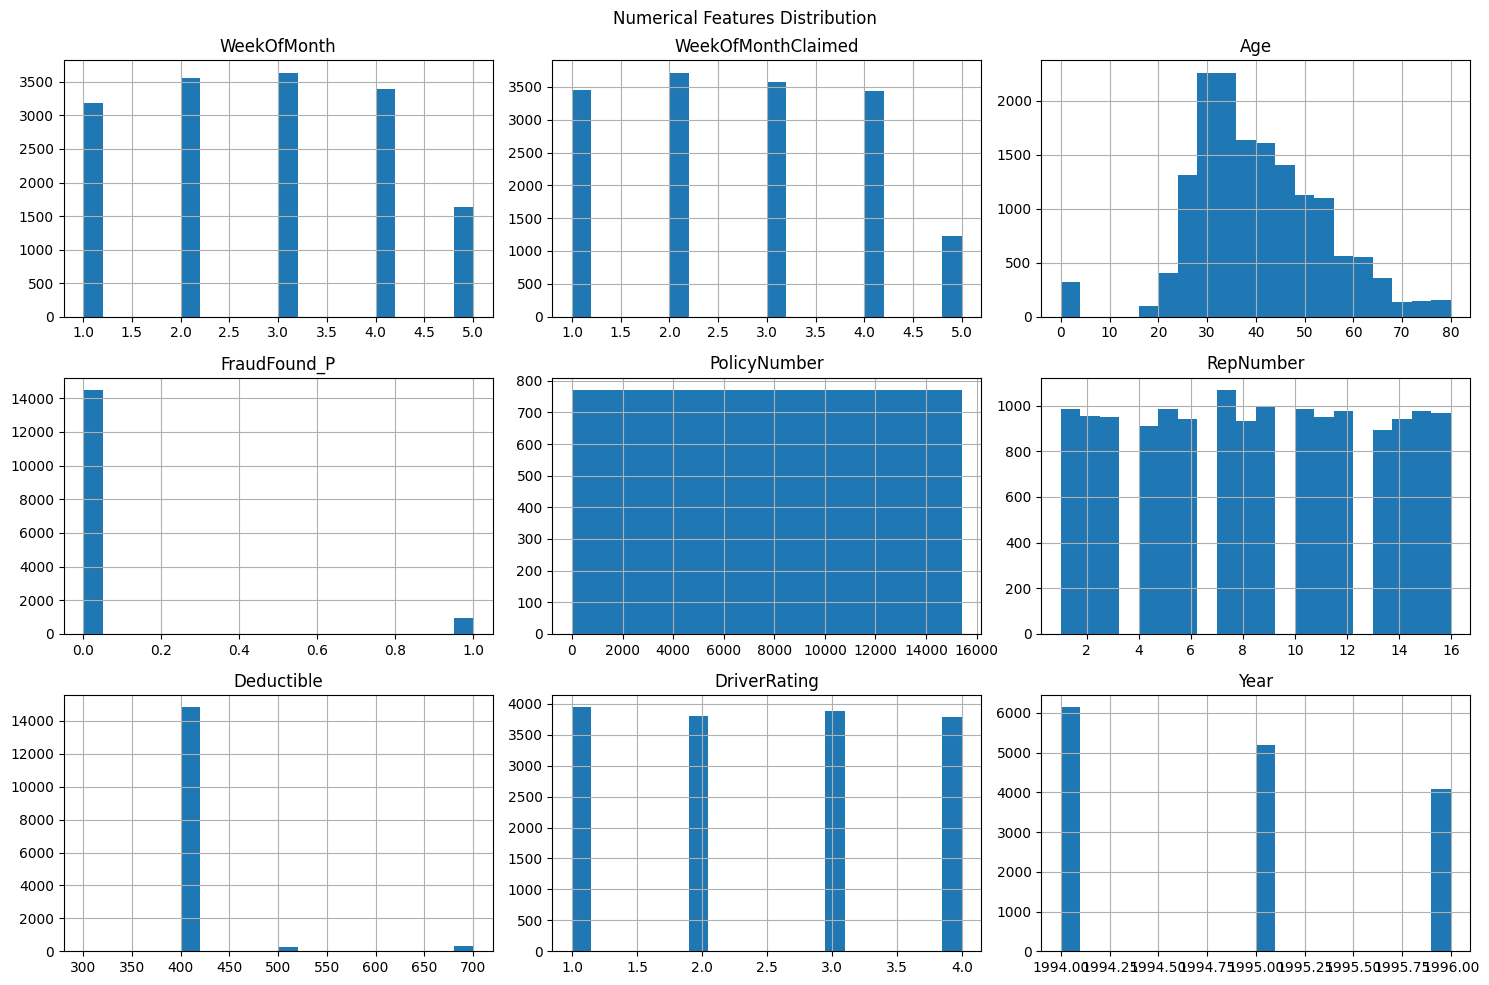

In [33]:
# 1. Univariate - Numerical columns
df.hist(figsize=(15,10), bins=20)
plt.suptitle('Numerical Features Distribution')
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_15120\2856004740.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FraudFound_P', data=df, palette='Set2')


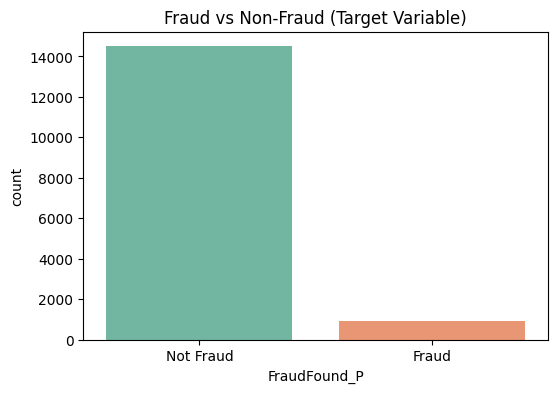

In [34]:
# 2. Fraud Distribution Plot
plt.figure(figsize=(6,4))
sns.countplot(x='FraudFound_P', data=df, palette='Set2')
plt.title('Fraud vs Non-Fraud (Target Variable)')
plt.xticks([0,1], ['Not Fraud', 'Fraud'])
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_15120\3346707953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FraudFound_P', data=df, y='Age', palette='Set2')


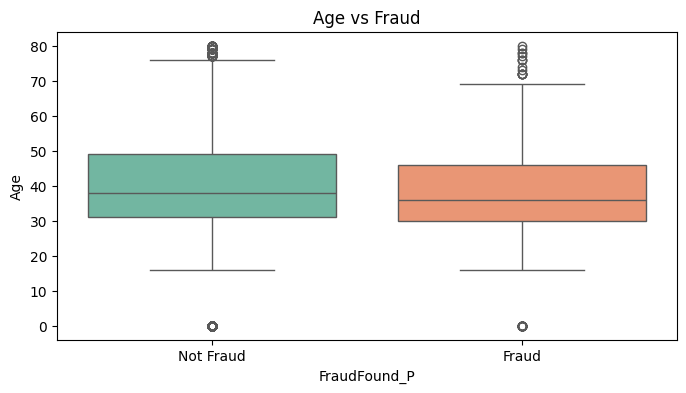

In [35]:
# 3. Bivariate - Fraud vs Age
plt.figure(figsize=(8,4))
sns.boxplot(x='FraudFound_P', data=df, y='Age', palette='Set2')
plt.title('Age vs Fraud')
plt.xticks([0,1], ['Not Fraud', 'Fraud'])
plt.show()

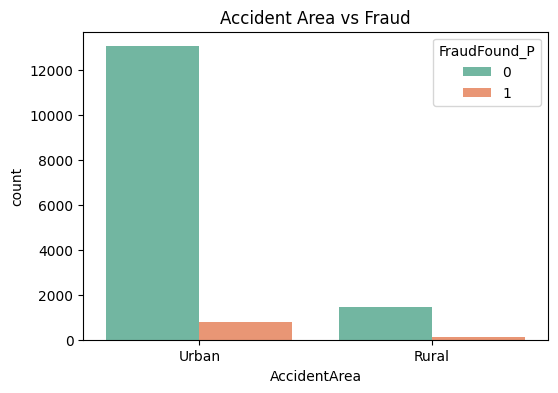

In [36]:
# 4. Categorical - Fraud by AccidentArea
plt.figure(figsize=(6,4))
sns.countplot(x='AccidentArea', hue='FraudFound_P', data=df, palette='Set2')
plt.title('Accident Area vs Fraud')
plt.show()


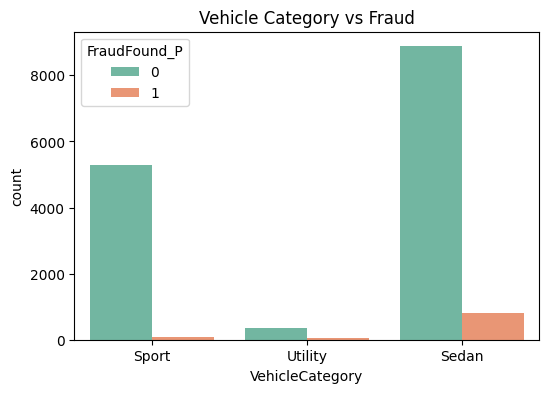

In [37]:
# 5. Fraud by VehicleCategory
plt.figure(figsize=(6,4))
sns.countplot(x='VehicleCategory', hue='FraudFound_P', data=df, palette='Set2')
plt.title('Vehicle Category vs Fraud')
plt.show()

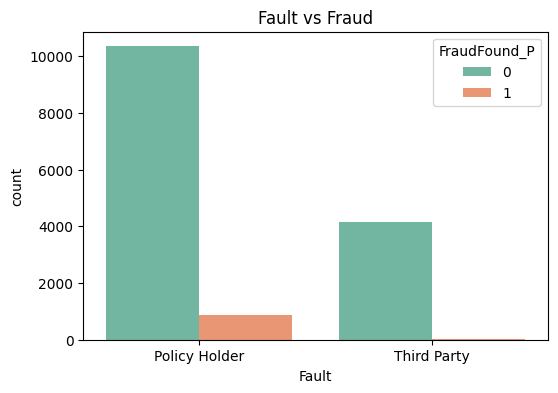

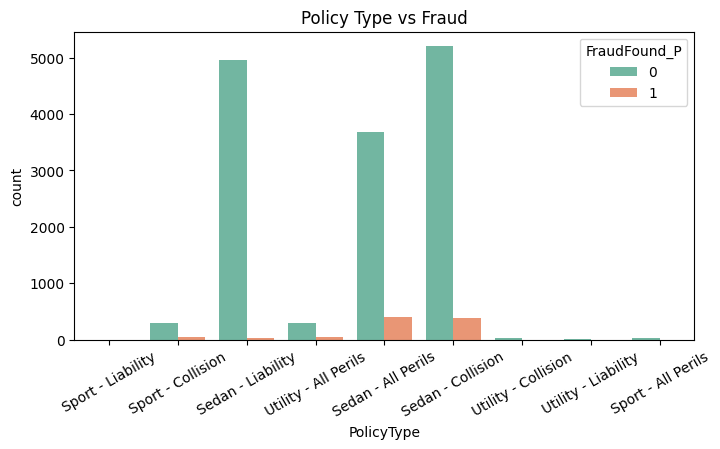

In [38]:
# Fraud by Fault
plt.figure(figsize=(6,4))
sns.countplot(x='Fault', hue='FraudFound_P', data=df, palette='Set2')
plt.title('Fault vs Fraud')
plt.show()

# Fraud by PolicyType
plt.figure(figsize=(8,4))
sns.countplot(x='PolicyType', hue='FraudFound_P', data=df, palette='Set2')
plt.title('Policy Type vs Fraud')
plt.xticks(rotation=30)
plt.show()

In [39]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print(f"Total Duplicate Records: {duplicate_count}")

if duplicate_count > 0:
    print("\nRemoving duplicate records...")
    df = df.drop_duplicates()
    print(f"New Dataset Shape: {df.shape}")
else:
    print("No duplicate records found.")

Total Duplicate Records: 0
No duplicate records found.


In [40]:
#outliers detection
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numerical_cols)

Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'FraudFound_P',
       'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year'],
      dtype='object')


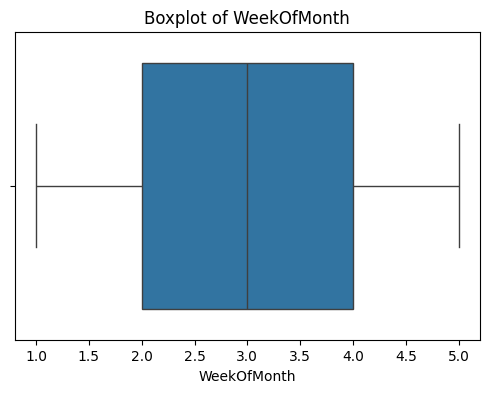

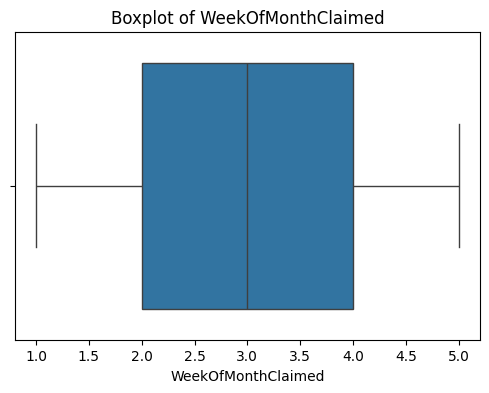

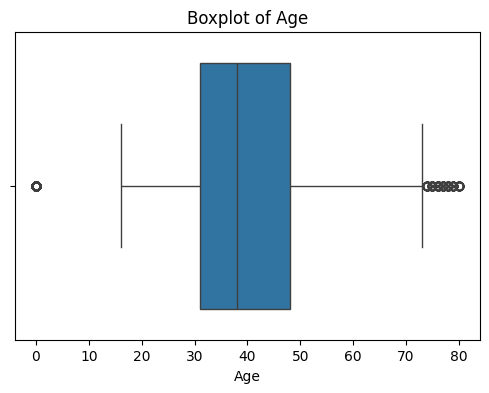

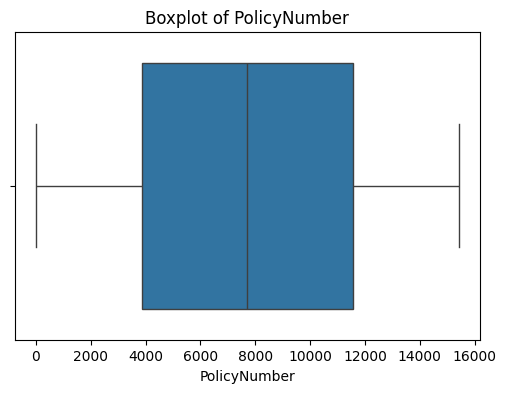

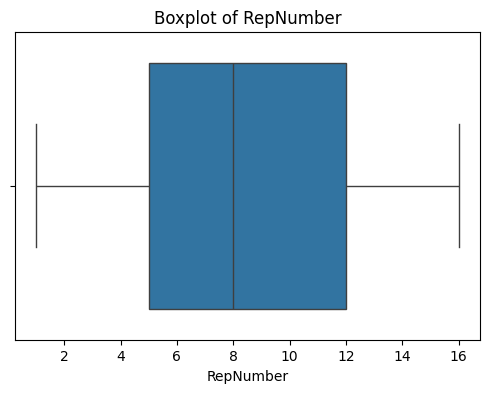

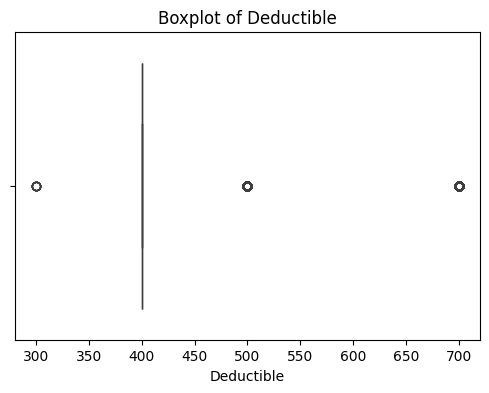

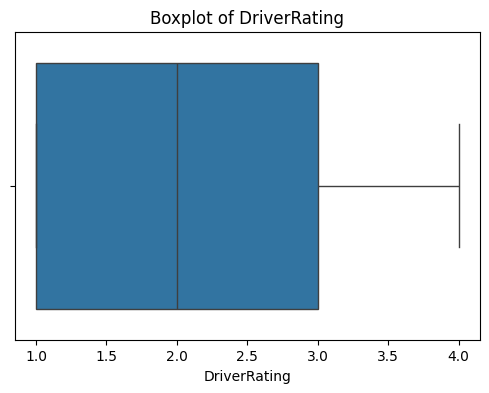

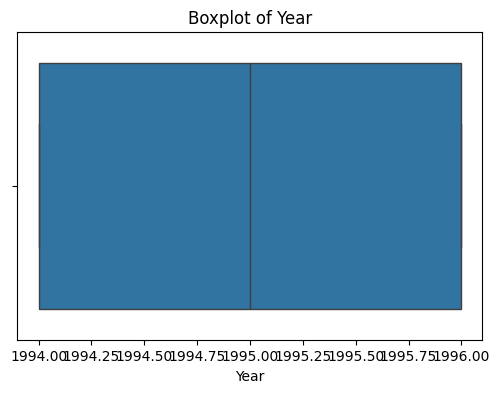

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    if col != "FraudFound_P":
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.show()

In [42]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
Month,object,0,12
WeekOfMonth,int64,0,5
DayOfWeek,object,0,7
Make,object,0,19
AccidentArea,object,0,2
DayOfWeekClaimed,object,0,8
MonthClaimed,object,0,13
WeekOfMonthClaimed,int64,0,5
Sex,object,0,2
MaritalStatus,object,0,4


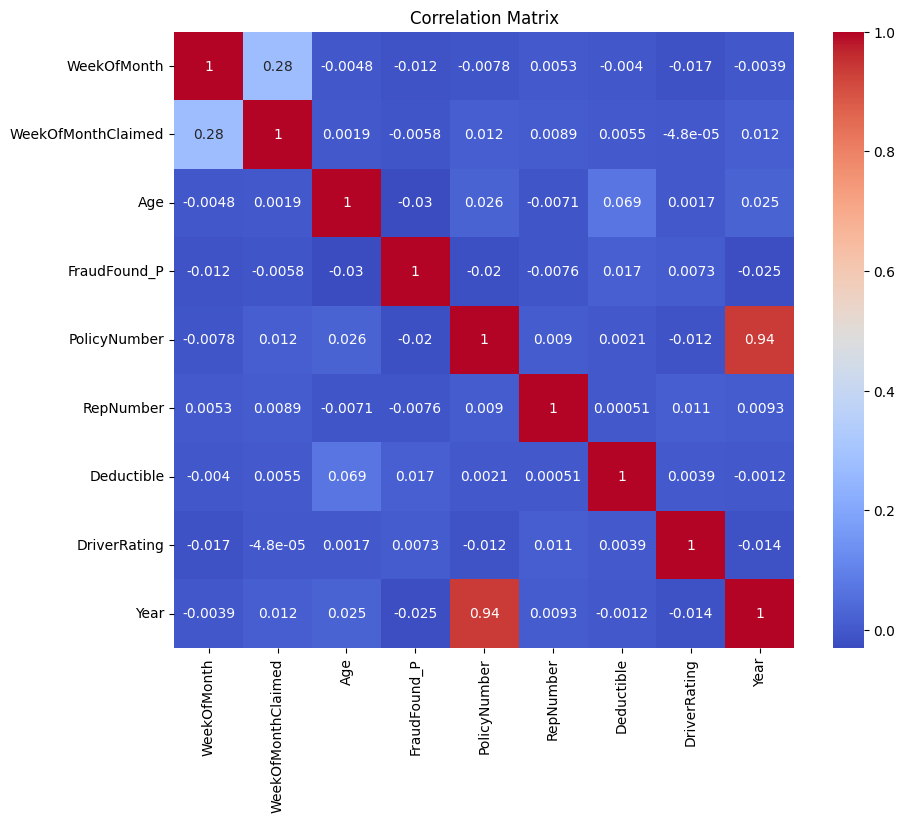

In [43]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [44]:
print("="*60)
print("FEATURE SUMMARY")
print("="*60)

print(f"Total Features          : {df.shape[1]-1}")
print(f"Numerical Features      : {len(numerical_cols)-1}")
print(f"Categorical Features    : {df.shape[1] -len(numerical_cols) }")
print(f"Target Variable         : FraudFound_P")

FEATURE SUMMARY
Total Features          : 32
Numerical Features      : 8
Categorical Features    : 24
Target Variable         : FraudFound_P


## Key EDA Findings

1. Dataset contains 15,420 insurance claim records with 33 features.

2. No missing values or duplicate records were found.

3. Target variable is highly imbalanced:
   - Fraud ≈ 6%
   - Non-Fraud ≈ 94%

4. Most predictor variables are categorical and require encoding.

5. Numerical variables showed different value ranges, indicating scaling would be useful for distance-based models.

6. Certain variables such as AccidentArea, PolicyType and Fault showed noticeable differences between fraud and non-fraud claims.

7. The severe class imbalance suggested that resampling techniques such as SMOTE would be required before model training.

##  DATA PREPROCESSING

In [45]:
!pip install imbalanced-learn

In [46]:
# Create a copy of the dataset
df = df.copy()

# Drop identifier columns
df = df.drop(columns=["PolicyNumber", "RepNumber"])

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (15420, 31)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [70]:
print(df.dtypes)

Month                   object
WeekOfMonth              int64
DayOfWeek               object
Make                    object
AccidentArea            object
DayOfWeekClaimed        object
MonthClaimed            object
WeekOfMonthClaimed       int64
Sex                     object
MaritalStatus           object
Age                      int64
Fault                   object
PolicyType              object
VehicleCategory         object
VehiclePrice            object
FraudFound_P             int64
Deductible               int64
DriverRating             int64
Days_Policy_Accident    object
Days_Policy_Claim       object
PastNumberOfClaims      object
AgeOfVehicle            object
AgeOfPolicyHolder       object
PoliceReportFiled       object
WitnessPresent          object
AgentType               object
NumberOfSuppliments     object
AddressChange_Claim     object
NumberOfCars            object
Year                     int64
BasePolicy              object
dtype: object


In [71]:
# Features
X = df.drop("FraudFound_P", axis=1)

# Target
y = df["FraudFound_P"]

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (15420, 30)
Target Shape : (15420,)


# Train-test split

In [72]:


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (12336, 30)
Testing Set  : (3084, 30)


In [73]:
# one hot enchoding
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(include="object").columns
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Columns:", len(categorical_cols))
print("Numerical Columns:", len(numerical_cols))

Categorical Columns: 24
Numerical Columns: 6


In [74]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit only on training data
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])

# Transform test data
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [75]:
import pandas as pd

encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

In [76]:
X_train_final = pd.concat(
    [X_train[numerical_cols], X_train_encoded],
    axis=1
)

X_test_final = pd.concat(
    [X_test[numerical_cols], X_test_encoded],
    axis=1
)

print(X_train_final.shape)
print(X_test_final.shape)

(12336, 146)
(3084, 146)


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final[numerical_cols] = scaler.fit_transform(
    X_train_final[numerical_cols]
)

X_test_final[numerical_cols] = scaler.transform(
    X_test_final[numerical_cols]
)

# SMOTE-(FOR CLASS IMBALANCE)

In [78]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_final,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(23196, 146)
FraudFound_P
0    11598
1    11598
Name: count, dtype: int64


In [79]:
print("Training Class Distribution Before SMOTE")
print(y_train.value_counts())
print("\nPercentage")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTraining Class Distribution After SMOTE")
print(y_train_smote.value_counts())
print("\nPercentage")
print((y_train_smote.value_counts(normalize=True) * 100).round(2))

Training Class Distribution Before SMOTE
FraudFound_P
0    11598
1      738
Name: count, dtype: int64

Percentage
FraudFound_P
0    94.02
1     5.98
Name: proportion, dtype: float64

Training Class Distribution After SMOTE
FraudFound_P
0    11598
1    11598
Name: count, dtype: int64

Percentage
FraudFound_P
0    50.0
1    50.0
Name: proportion, dtype: float64


In [53]:
#Train all the models

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)

print("All models trained successfully!")

All models trained successfully!


In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for name, model in models.items():

    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XGBoost,0.940986,0.545455,0.097297,0.165138,0.856823
2,Random Forest,0.940986,1.000000,0.016216,0.031915,0.826071
0,Logistic Regression,0.664073,0.130963,0.816216,0.225710,0.802176
3,SVM,0.906615,0.218579,0.216216,0.217391,0.794917
1,Decision Tree,0.892348,0.167421,0.200000,0.182266,0.568265


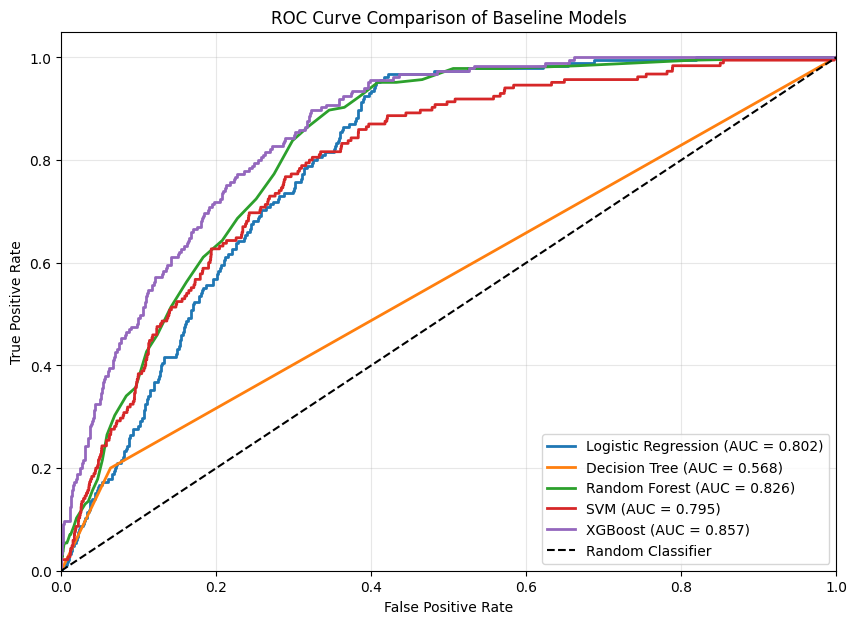

In [88]:
#ROC-AUC CURVE
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

for name, model in models.items():

    # Probability predictions
    y_prob = model.predict_proba(X_test_final)[:,1]

    # ROC values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # AUC
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    label="Random Classifier"
)

plt.xlim([0,1])
plt.ylim([0,1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Baseline Models")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

# Model Selection:


### Based on the baseline evaluation, XGBoost achieved the highest ROC-AUC score (0.857), indicating the best overall ability to distinguish fraudulent from legitimate claims across different classification thresholds. Therefore, XGBoost was selected for hyperparameter tuning using GridSearchCV.

In [85]:
# Grid serach CV and hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [86]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}

Best CV Score:
0.993032028195453


In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Best model from GridSearchCV
best_xgb = grid_search.best_estimator_

# Predictions
y_pred = best_xgb.predict(X_test_final)
y_prob = best_xgb.predict_proba(X_test_final)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9416342412451362
Precision: 0.6923076923076923
Recall   : 0.04864864864864865
F1 Score : 0.09090909090909091
ROC-AUC  : 0.8475373614387067

Confusion Matrix
[[2895    4]
 [ 176    9]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.69      0.05      0.09       185

    accuracy                           0.94      3084
   macro avg       0.82      0.52      0.53      3084
weighted avg       0.93      0.94      0.92      3084



In [61]:
print(X_train.dtypes.value_counts())

float64    30
Name: count, dtype: int64


<Figure size 600x600 with 0 Axes>

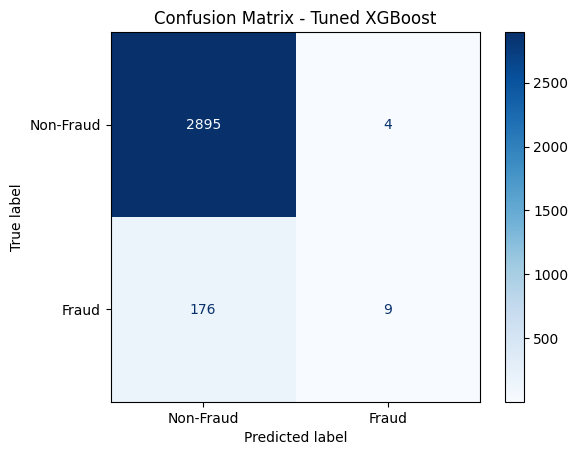

In [90]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Fraud", "Fraud"]
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

## Observations

### The model achieved an accuracy of 94.16% on the test set.
### The ROC-AUC score of 0.848 indicates good overall discrimination between fraudulent and legitimate claims.
### Precision was relatively high (69.2%), indicating that when the model predicted fraud, it was usually correct.
### Recall was relatively low (4.9%), meaning many fraudulent claims were still missed.
### This suggests the model is conservative in predicting fraud and prioritizes avoiding false positives over capturing all fraudulent claims.

# FEATURE IMPORTANCE

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": best_xgb.feature_importances_
})

# Sort
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
145,BasePolicy_Liability,0.228776
73,Fault_Policy Holder,0.127001
134,AddressChange_Claim_2 to 3 years,0.055572
132,NumberOfSuppliments_none,0.024090
64,MonthClaimed_Nov,0.019743
24,DayOfWeek_Wednesday,0.018017
23,DayOfWeek_Tuesday,0.017964
76,PolicyType_Sedan - Collision,0.016285
38,Make_Pontiac,0.016183
18,DayOfWeek_Friday,0.015645


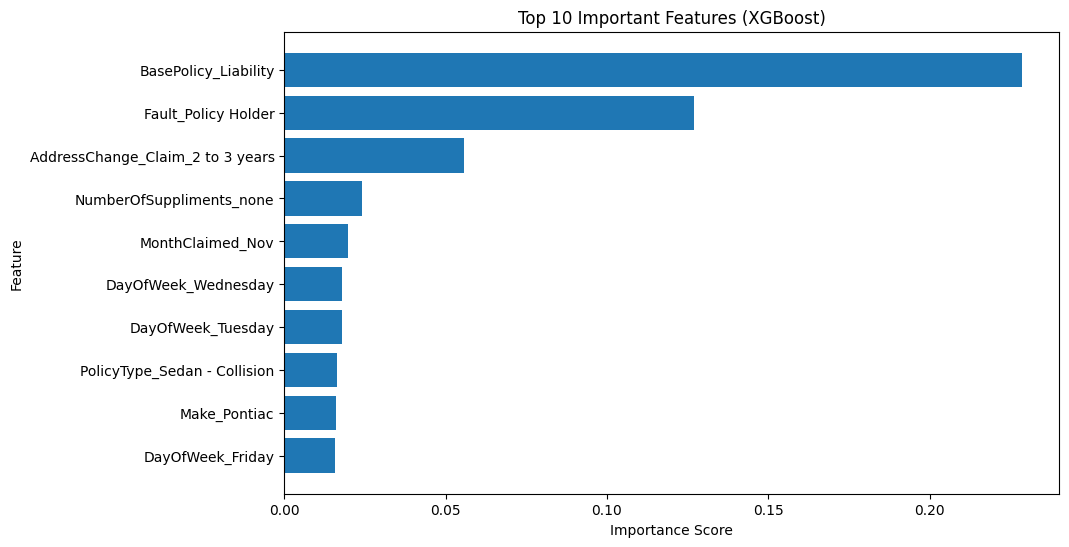

In [92]:
plt.figure(figsize=(10,6))

top10 = feature_importance.head(10)

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Important Features (XGBoost)")

plt.show()

In [93]:
# Save feature importance table
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,BasePolicy_Liability,0.228776
1,Fault_Policy Holder,0.127001
2,AddressChange_Claim_2 to 3 years,0.055572
3,NumberOfSuppliments_none,0.024090
4,MonthClaimed_Nov,0.019743
5,DayOfWeek_Wednesday,0.018017
6,DayOfWeek_Tuesday,0.017964
7,PolicyType_Sedan - Collision,0.016285
8,Make_Pontiac,0.016183
9,DayOfWeek_Friday,0.015645


In [94]:
# EXPORT TO CSV
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [95]:
feature_importance["Importance (%)"] = (
    feature_importance["Importance"]
    / feature_importance["Importance"].sum()
) * 100

feature_importance.head(15)

,Feature,Importance,Importance (%)
0,BasePolicy_Liability,0.228776,22.877600
1,Fault_Policy Holder,0.127001,12.700052
2,AddressChange_Claim_2 to 3 years,0.055572,5.557157
3,NumberOfSuppliments_none,0.024090,2.408994
4,MonthClaimed_Nov,0.019743,1.974338
5,DayOfWeek_Wednesday,0.018017,1.801654
6,DayOfWeek_Tuesday,0.017964,1.796364
7,PolicyType_Sedan - Collision,0.016285,1.628466
8,Make_Pontiac,0.016183,1.618318
9,DayOfWeek_Friday,0.015645,1.564543


In [96]:
# CUMULATIVE IMPORTANCE
feature_importance["Cumulative Importance (%)"] = (
    feature_importance["Importance (%)"].cumsum()
)

feature_importance.head(15)

,Feature,Importance,Importance (%),Cumulative Importance (%)
0,BasePolicy_Liability,0.228776,22.877600,22.877600
1,Fault_Policy Holder,0.127001,12.700052,35.577652
2,AddressChange_Claim_2 to 3 years,0.055572,5.557157,41.134808
3,NumberOfSuppliments_none,0.024090,2.408994,43.543800
4,MonthClaimed_Nov,0.019743,1.974338,45.518139
5,DayOfWeek_Wednesday,0.018017,1.801654,47.319794
6,DayOfWeek_Tuesday,0.017964,1.796364,49.116158
7,PolicyType_Sedan - Collision,0.016285,1.628466,50.744621
8,Make_Pontiac,0.016183,1.618318,52.362938
9,DayOfWeek_Friday,0.015645,1.564543,53.927483


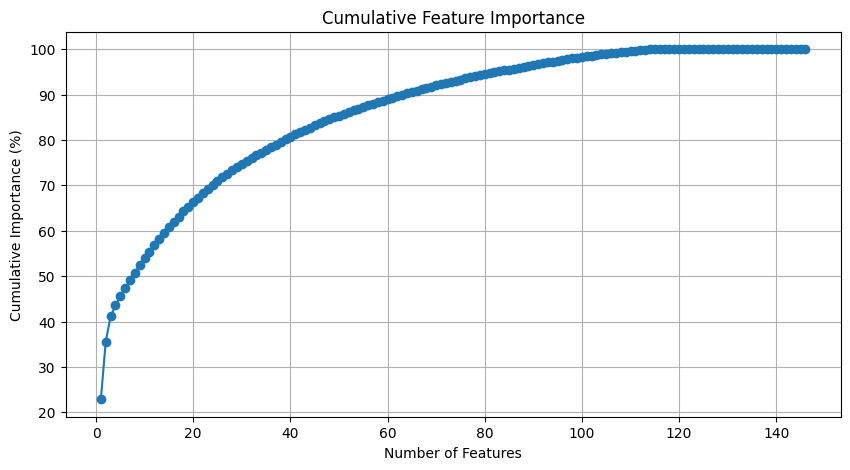

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(feature_importance)+1),
    feature_importance["Cumulative Importance (%)"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance (%)")
plt.title("Cumulative Feature Importance")

plt.grid(True)

plt.show()

In [98]:
# Select Top 20 important features
top_features = feature_importance.head(20)["Feature"].tolist()

print("Number of Selected Features:", len(top_features))
print(top_features)

Number of Selected Features: 20
['BasePolicy_Liability', 'Fault_Policy Holder', 'AddressChange_Claim_2 to 3 years', 'NumberOfSuppliments_none', 'MonthClaimed_Nov', 'DayOfWeek_Wednesday', 'DayOfWeek_Tuesday', 'PolicyType_Sedan - Collision', 'Make_Pontiac', 'DayOfWeek_Friday', 'DayOfWeekClaimed_Thursday', 'DayOfWeekClaimed_Monday', 'Month_Jul', 'DayOfWeek_Thursday', 'DayOfWeek_Saturday', 'Make_Toyota', 'Sex_Female', 'Make_Chevrolet', 'Make_Mazda', 'VehiclePrice_20000 to 29000']


In [99]:
X_train_selected = X_train_smote[top_features]

X_test_selected = X_test_final[top_features]

print(X_train_selected.shape)
print(X_test_selected.shape)

(23196, 20)
(3084, 20)


In [100]:
xgb_selected = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    colsample_bytree=1.0,
    learning_rate=0.1,
    max_depth=7,
    n_estimators=100,
    subsample=0.8
)

xgb_selected.fit(
    X_train_selected,
    y_train_smote
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [101]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score

y_pred = xgb_selected.predict(X_test_selected)
y_prob = xgb_selected.predict_proba(X_test_selected)[:,1]

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC-AUC  :", roc_auc_score(y_test,y_prob))

Accuracy : 0.9348249027237354
Precision: 0.34615384615384615
Recall   : 0.0972972972972973
F1 Score : 0.1518987341772152
ROC-AUC  : 0.8212999822865295


# Final Conclusion

This project aimed to develop a machine learning model for detecting fraudulent vehicle insurance claims using historical claim data.

A comprehensive machine learning pipeline was implemented, including exploratory data analysis, preprocessing, One-Hot Encoding, feature scaling, SMOTE-based class balancing, baseline model comparison, hyperparameter tuning, and feature importance analysis.

Among the evaluated models, XGBoost achieved the highest baseline ROC-AUC score and was selected for further optimization using GridSearchCV. Although hyperparameter tuning produced a high cross-validation ROC-AUC, the tuned model did not improve performance on the unseen test data, demonstrating the importance of evaluating models on independent test sets.

Feature importance analysis showed that policy-related variables such as BasePolicy, Fault, AddressChange_Claim, and PolicyType contributed most to fraud prediction. A feature selection experiment using the top 20 features was also conducted. However, retaining the complete feature set resulted in better overall predictive performance.

Overall, this project demonstrates a complete end-to-end machine learning workflow for insurance fraud detection while emphasizing proper preprocessing, model evaluation, and explainability.

# Future Scope

Although the proposed solution provides a complete machine learning pipeline, several improvements can be explored in future work.

• Perform threshold tuning to optimize the trade-off between precision and recall for fraud detection.

• Compare SMOTE with alternative imbalance handling techniques such as ADASYN, Borderline-SMOTE, and class-weighted learning.

• Apply SHAP values or LIME to provide local explanations for individual fraud predictions.

• Evaluate additional ensemble methods such as LightGBM and CatBoost.

• Deploy the trained model using Flask or FastAPI to build a real-time fraud prediction service.

• Continuously retrain the model as new insurance claim data becomes available to adapt to evolving fraud patterns.